# Customer Segmentation using RFM Analysis + K-Means Clustering

**Dataset:** Online Retail Dataset — UCI Machine Learning Repository  
**Domain:** E-commerce / Retail Analytics  
**Techniques:** RFM Analysis, K-Means Clustering, Data Cleaning, Feature Scaling  
**Tools:** Python, Pandas, NumPy, Scikit-learn, Matplotlib

---

## Objective
Segment customers of a UK-based online retailer into distinct behavioral groups 
using RFM (Recency, Frequency, Monetary) analysis and K-Means clustering. 
The goal is to identify which customers drive the most revenue, which are at risk 
of churning, and what actions the business should take for each group.

## Dataset Overview
- **Source:** UCI Online Retail Dataset
- **Period:** December 2010 – December 2011
- **Raw Size:** 541,909 transactions
- **Columns:** InvoiceNo, StockCode, Description, Quantity, InvoiceDate, 
  UnitPrice, CustomerID, Country

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.2 MB 2.9 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.2 MB 2.4 MB/s eta 0:00:03
   -------- ------------------------------- 1.8/8.2 MB 2.3 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.2 MB 2.2 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.2 MB 2.1 MB/s eta 0:00:03
   -------------- ------------------------- 2.9/8.2 MB 2.1 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.2 MB 2.0 MB/s eta 0:00:03
   ----------------- ---------------------- 3.7/8.2 MB 1.9 MB/s eta 0:00:03
   ------------------- -------------------- 3.9/8.2 MB 1.9 MB/s eta 0:00:03
   -------------------- ------------------- 4.2/8.2 MB 1.8 MB/s eta 0:00:03
   ---------------------


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
import pandas as pd

## Step 1: Data Cleaning

Raw transaction data is rarely clean enough to analyze directly. 
This step removes noise that would corrupt our RFM calculations:

- **Cancelled orders** — Invoices starting with 'C' and negative quantities 
  represent returns/reversals, not real purchases
- **Missing CustomerIDs** — ~25% of rows have no customer identifier and 
  cannot be attributed to anyone for RFM analysis
- **Zero/negative prices** — Free items, data entry errors, and adjustment 
  rows that don't represent real revenue
- **Price outliers** — Extreme unit prices (bottom 1% and top 1%) that could 
  distort monetary calculations
- **Duplicate rows** — Exact duplicate entries likely caused by data entry errors

A `TotalPrice` column (Quantity × UnitPrice) is created here as it will be 
needed to calculate Monetary value in Step 2.

In [42]:
#Load data
df = pd.read_excel("Online Retail.xlsx")

In [43]:
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [44]:
print(df.shape)

(541909, 8)


In [45]:
print(df.describe())

            Quantity                    InvoiceDate      UnitPrice  \
count  541909.000000                         541909  541909.000000   
mean        9.552250  2011-07-04 13:34:57.156386048       4.611114   
min    -80995.000000            2010-12-01 08:26:00  -11062.060000   
25%         1.000000            2011-03-28 11:34:00       1.250000   
50%         3.000000            2011-07-19 17:17:00       2.080000   
75%        10.000000            2011-10-19 11:27:00       4.130000   
max     80995.000000            2011-12-09 12:50:00   38970.000000   
std       218.081158                            NaN      96.759853   

          CustomerID  
count  406829.000000  
mean    15287.690570  
min     12346.000000  
25%     13953.000000  
50%     15152.000000  
75%     16791.000000  
max     18287.000000  
std      1713.600303  


In [46]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [47]:
#Removed cancelled orders (Invoice starting with 'C' or negative Quantity)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity']>0]

In [48]:
#Remove missing CustomerId
df = df.dropna(subset=['CustomerID'])

In [49]:
#Remove zero or negative price rows
df = df[df['UnitPrice']>0]

In [50]:
#Cap extreme outliers (e.g. using quantile capping
q_low = df['UnitPrice'].quantile(0.01)
q_high = df['UnitPrice'].quantile(0.99)
df = df[(df['UnitPrice'] >= q_low) & (df['UnitPrice'] <= q_high)]

In [51]:
# Create a TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [52]:
#CustomerID is consistent type
df['CustomerID'] = df['CustomerID'].astype(int)

In [53]:
#Handle duplicates
print(df.duplicated().sum())

5140


In [54]:
df = df.drop_duplicates()

In [55]:
#Making sure data has proper values
df['StockCode'].value_counts().head(20)

StockCode
85123A    2023
22423     1703
85099B    1615
84879     1395
47566     1389
20725     1304
22720     1152
23203     1091
20727     1078
22383     1063
22197     1060
21212     1050
23298     1021
23209     1020
22086     1003
22382      993
22469      979
20728      977
22457      972
22384      941
Name: count, dtype: int64

In [56]:
#and types
print(df['InvoiceDate'].dtype)

datetime64[ns]


In [57]:
#Check
print(df.shape)
print(df.isnull().sum())

(386019, 9)
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64


In [58]:
print(df['Quantity'].min())
print(df['UnitPrice'].min())

1
0.21


## Step 2: Building the RFM Table

RFM compresses thousands of transaction rows into a single behavioral 
summary per customer — three numbers that describe their entire relationship 
with the business:

- **Recency (R):** Days since their last purchase, measured from a fixed 
  snapshot date (one day after the last transaction in the dataset). 
  Lower = more recent = better.
- **Frequency (F):** Number of distinct orders placed (unique InvoiceNo count). 
  Higher = more loyal.
- **Monetary (M):** Total amount spent across all orders (sum of TotalPrice). 
  Higher = more valuable.

This reduces ~386,000 cleaned transaction rows down to one row per unique 
customer — the table that K-Means will cluster in Step 3.

In [59]:
import datetime as dt

In [61]:
#Set a reference "snapshot" date — 1 day after the last transaction
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
print("Snapshot Date:", snapshot_date)

Snapshot Date: 2011-12-10 12:50:00


In [63]:
#Build RFM table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

In [64]:
#Rename columns
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

In [65]:
print(rfm.shape)

(4325, 3)


In [66]:
print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346           326          1  77183.60
12347             2          7   4310.00
12348            75          4   1437.24
12349            19          1   1353.80
12350           310          1    294.40


In [67]:
print(rfm.describe())

           Recency    Frequency       Monetary
count  4325.000000  4325.000000    4325.000000
mean     92.525318     4.243006    1980.563588
std     100.048779     7.608567    8790.931519
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     296.580000
50%      51.000000     2.000000     652.550000
75%     143.000000     5.000000    1610.150000
max     374.000000   203.000000  278162.260000


## Step 3A: Preprocessing — Log Transform + Scaling

Before clustering, the RFM data needs two transformations:

**1. Log Transform (Frequency and Monetary)**  
Customer spending follows a Pareto distribution — a small number of customers 
spend dramatically more than everyone else. The Monetary column has a mean of 
£1,980 but a max of £278,162, making it heavily right-skewed. K-Means uses 
Euclidean distance, which would be completely dominated by these extreme values 
without correction. `log1p` compresses large values more aggressively than 
small ones, making the distribution far more symmetric.

**2. StandardScaler**  
Even after log-transforming, Recency (days), Frequency (orders), and Monetary 
(log-pounds) are in different units with different ranges. StandardScaler 
converts each column to mean=0 and std=1, ensuring no single column 
dominates distance calculations purely because of its numeric scale.

Both steps are necessary — log-transform fixes the *shape* of the distribution, 
scaling fixes the *units*.

In [69]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [70]:
# Log-transform Frequency and Monetary
rfm_log = rfm.copy()
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

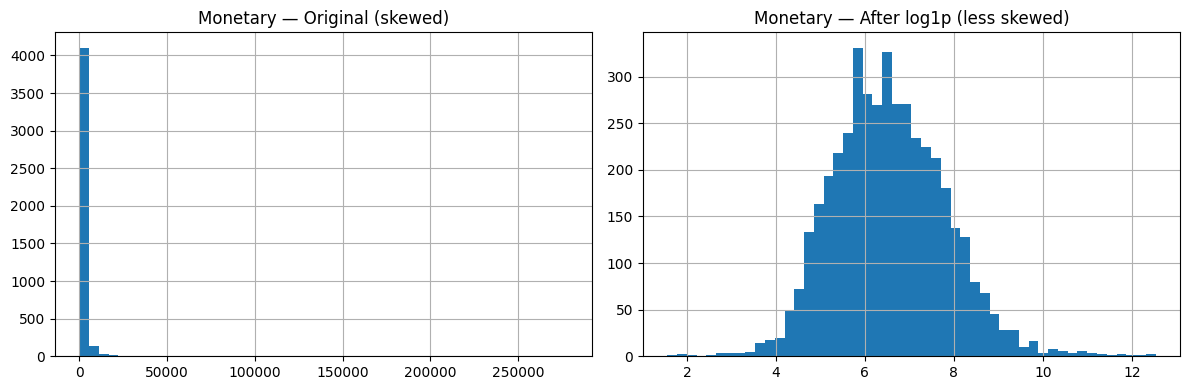

In [88]:
# Quick check — Monetary distribution before vs after
fig, axes = plt.subplots(1, 2, figsize=(12,4))

rfm['Monetary'].hist(bins=50, ax=axes[0])
axes[0].set_title('Monetary — Original (skewed)')

rfm_log['Monetary'].hist(bins=50, ax=axes[1])
axes[1].set_title('Monetary — After log1p (less skewed)')

plt.tight_layout()
plt.show()

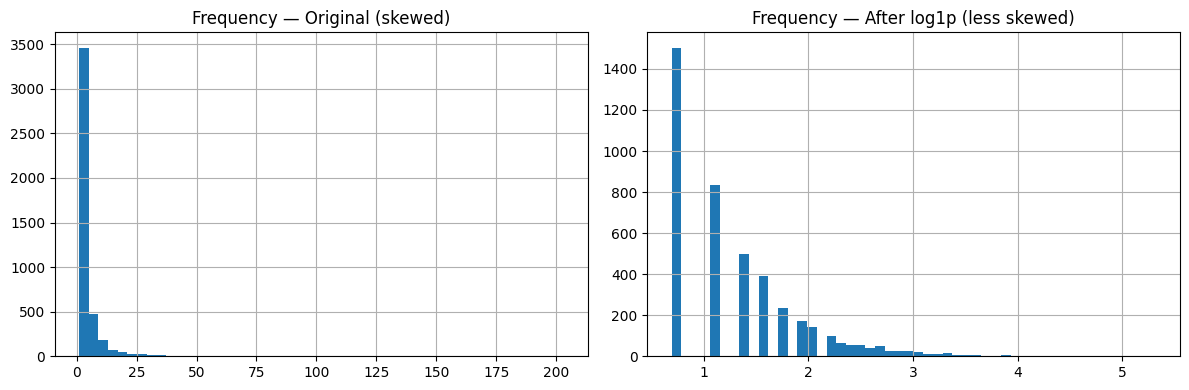

In [93]:
# Quick check — Frequency distribution before vs after
fig, axes = plt.subplots(1, 2, figsize=(12,4))

rfm['Frequency'].hist(bins=50, ax=axes[0])
axes[0].set_title('Frequency — Original (skewed)')

rfm_log['Frequency'].hist(bins=50, ax=axes[1])
axes[1].set_title('Frequency — After log1p (less skewed)')

plt.tight_layout()
plt.show()

In [91]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[['Recency', 'Frequency', 'Monetary']])
#after fit and transform, mean=0 and std=1

In [92]:
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'], index=rfm.index)
print(rfm_scaled.describe())

            Recency     Frequency      Monetary
count  4.325000e+03  4.325000e+03  4.325000e+03
mean  -5.339338e-17  1.355371e-16  1.642873e-16
std    1.000116e+00  1.000116e+00  1.000116e+00
min   -9.149127e-01 -9.505850e-01 -3.952110e+00
25%   -7.449760e-01 -9.505850e-01 -6.768453e-01
50%   -4.150987e-01 -3.558246e-01 -5.406707e-02
75%    5.045591e-01  6.609249e-01  6.601790e-01
max    2.813700e+00  5.833600e+00  4.737904e+00


In [94]:
print(rfm_scaled.mean().round(5))

Recency     -0.0
Frequency    0.0
Monetary     0.0
dtype: float64


In [95]:
print(rfm_scaled.std().round(5))

Recency      1.00012
Frequency    1.00012
Monetary     1.00012
dtype: float64


## Step 3B: Choosing K — Elbow Method + Silhouette Score

K-Means requires you to specify the number of clusters (K) upfront. 
Two methods are used together to make this decision objectively:

**Elbow Method**  
Runs K-Means for K=1 through K=10 and plots inertia (sum of squared distances 
from each point to its cluster centroid) against K. Inertia always decreases 
as K increases, but the rate of decrease slows at the "elbow" — the point 
where adding more clusters gives diminishing returns.

**Silhouette Score**  
Measures how well-separated clusters are. For each customer it compares 
their distance to their own cluster vs. the nearest other cluster. 
Scores range from -1 (wrong cluster) to +1 (well inside its cluster). 
Higher is better. Unlike the elbow method, this gives a single objective 
score per K to compare directly.

Using both methods together reduces the subjectivity of picking K.

In [96]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

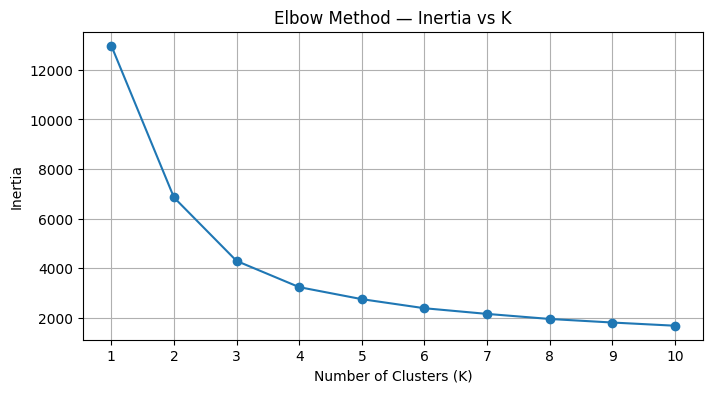

In [100]:
#Elbow method
inertia = []
K_range = range(1,11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method — Inertia vs K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True)
plt.show()

K=2 -> Silhouette Score: 0.4064
K=3 -> Silhouette Score: 0.4150
K=4 -> Silhouette Score: 0.3816
K=5 -> Silhouette Score: 0.3454
K=6 -> Silhouette Score: 0.3321
K=7 -> Silhouette Score: 0.3015
K=8 -> Silhouette Score: 0.3003
K=9 -> Silhouette Score: 0.2817
K=10 -> Silhouette Score: 0.2814


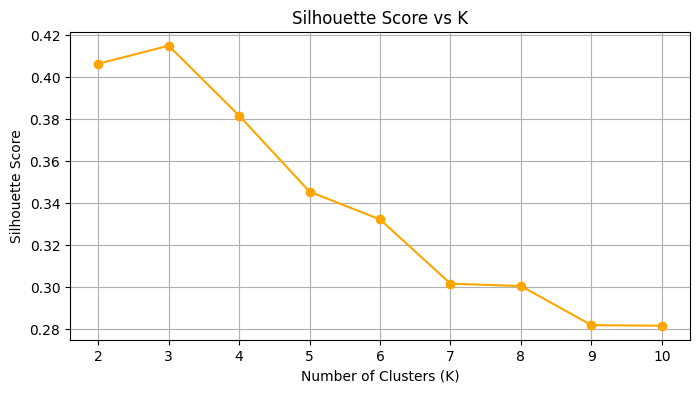

In [102]:
#Silhouette score
sil_scores = []
K_range_sil = range(2,11)

for k in K_range_sil:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    sil_scores.append(score)
    print(f"K={k} -> Silhouette Score: {score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(K_range_sil, sil_scores, marker='o', color='orange')
plt.title('Silhouette Score vs K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range_sil)
plt.grid(True)
plt.show()

## Step 3C: Fitting the Final K-Means Model

Both the elbow method and silhouette score pointed clearly to **K=3** as the 
optimal number of clusters:
- Elbow curve bends and flattens noticeably at K=3
- K=3 produced the highest silhouette score (0.4150)

The final model is fit with K=3 and cluster labels are attached back to the 
original (unscaled) RFM table so segments can be interpreted in real units 
(actual days and actual pounds, not scaled values).

In [103]:
final_k = 3
kmeans_final = KMeans(n_clusters=final_k, init='k-means++', n_init=10, random_state=42)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)
print(rfm['Cluster'].value_counts())

Cluster
0    2015
1    1325
2     985
Name: count, dtype: int64


In [104]:
print(rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2))

         Recency  Frequency  Monetary
Cluster                              
0          54.61       2.03    591.31
1          29.81       9.74   5272.90
2         254.45       1.38    393.76


## Step 4: Profiling and Labeling Segments

K-Means produces cluster numbers (0, 1, 2) — not business labels. 
This step interprets what each cluster actually means by examining 
the average Recency, Frequency, and Monetary values per cluster, 
then assigns a human-readable label based on that profile.

Labels are a business judgment call, not something the algorithm decides.

In [106]:
# Map cluster numbers to readable labels
cluster_labels = {
    0: 'Casual Customers',
    1: 'Champions',
    2: 'Lapsed Customers'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)

# Profile table — mean RFM per segment
profile = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
profile['Customer Count'] = rfm['Segment'].value_counts()
profile['% of Customers'] = (profile['Customer Count'] / len(rfm) * 100).round(1)
print(profile)

                  Recency  Frequency  Monetary  Customer Count  % of Customers
Segment                                                                       
Casual Customers    54.61       2.03    591.31            2015            46.6
Champions           29.81       9.74   5272.90            1325            30.6
Lapsed Customers   254.45       1.38    393.76             985            22.8


## Step 5: Visualizations

Two charts to communicate the segmentation visually:

**Scatter Plot — Recency vs Monetary (colored by segment)**  
Shows where each customer sits in RFM space and whether the clusters 
are visually distinct. A log scale is applied to the Y axis because 
a handful of extreme-spend customers would otherwise compress the 
majority of customers into an invisible line at the bottom.

**Bar Chart — Customer Count by Segment**  
Shows the size of each segment so we understand the scale of each 
customer group before drawing business conclusions.

In [107]:
import seaborn as sns

In [108]:
colors = {
    'Champions': '#2ecc71',
    'Casual Customers': '#3498db',
    'Lapsed Customers': '#e74c3c'

}    

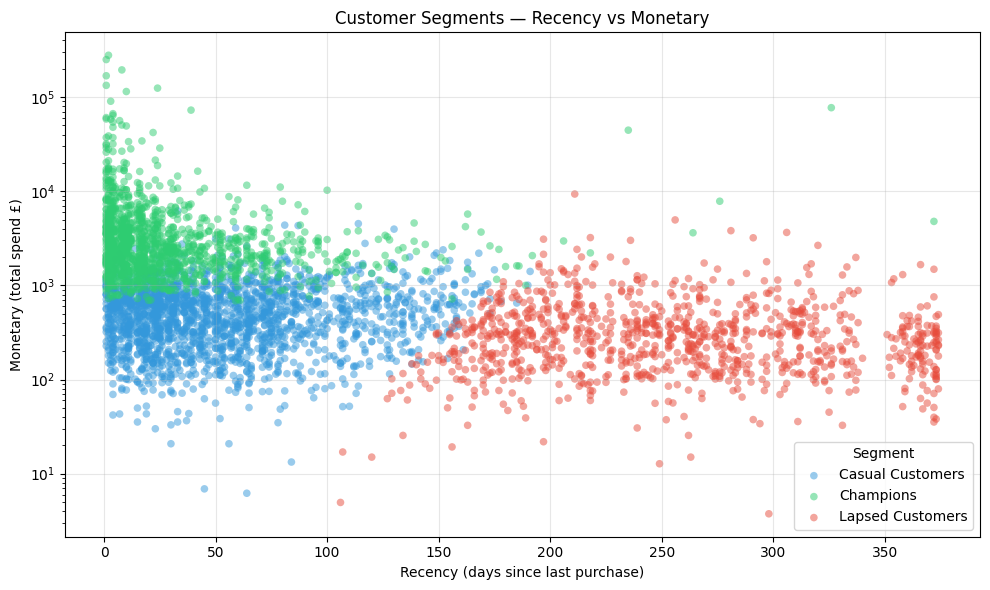

In [114]:
# --- Chart 1: Scatter plot — Recency vs Monetary ---
plt.figure(figsize=(10, 6))

for segment, group in rfm.groupby('Segment'):
    plt.scatter(
        group['Recency'],
        group['Monetary'],
        label=segment,
        alpha=0.5,
        color=colors[segment],
        edgecolors='none',
        s=30
    )

plt.title('Customer Segments — Recency vs Monetary')
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Monetary (total spend £)')
plt.yscale('log')  # Log scale on Y axis so outliers don't squash everyone else
plt.legend(title='Segment')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

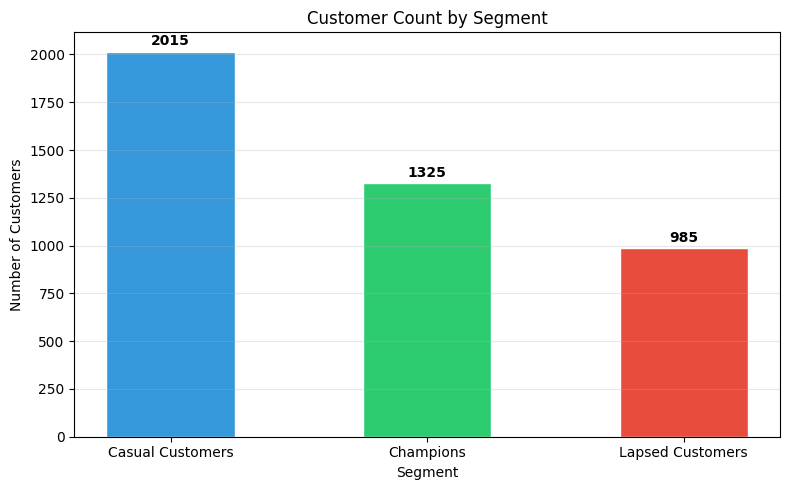

In [113]:
# --- Chart 2: Bar chart — Segment sizes ---
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(
    segment_counts.index,
    segment_counts.values,
    color=[colors[s] for s in segment_counts.index],
    edgecolor='white',
    width=0.5
)
# Add count labels on top of each bar
for bar, count in zip(bars, segment_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        str(count),
        ha='center',
        va='bottom',
        fontweight='bold'
    )
plt.title('Customer Count by Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6: Business Framing

The technical clustering is only useful if it drives real decisions. 
This step translates segment profiles into actionable business recommendations 
by calculating each segment's revenue contribution and identifying the 
appropriate strategy for each group.

In [118]:
#Revenue contribution per segment
revenue = rfm.groupby('Segment')['Monetary'].agg(['sum', 'mean', 'count'])
revenue.columns = ['Total Revenue', 'Avg Revenue per Customer', 'Customer Count']

revenue['% of Total Revenue'] = (revenue['Total Revenue']/revenue['Total Revenue'].sum() * 100).round(1)
revenue['% of Customers'] = (revenue['Customer Count'] / len(rfm) * 100).round(1)

revenue['Total Revenue'] = revenue['Total Revenue'].round(2)
revenue['Avg Revenue per Customer'] = revenue['Avg Revenue per Customer'].round(2)

print(revenue)

                  Total Revenue  Avg Revenue per Customer  Customer Count  \
Segment                                                                     
Casual Customers     1191495.90                    591.31            2015   
Champions            6986589.59                   5272.90            1325   
Lapsed Customers      387852.03                    393.76             985   

                  % of Total Revenue  % of Customers  
Segment                                               
Casual Customers                13.9            46.6  
Champions                       81.6            30.6  
Lapsed Customers                 4.5            22.8  


## Business Insights & Recommendations

### Overview
RFM analysis on 4,325 customers across a UK e-commerce retailer 
(Dec 2010 – Dec 2011) revealed three distinct customer segments 
with dramatically different revenue contributions.

---

### Segment 1: Champions (1,325 customers — 30.6%)
- Avg Recency: 29.81 days
- Avg Frequency: 9.74 orders
- Avg Monetary: £5,272.90
- Total Revenue: £6,986,589 (81.6% of all revenue)

**Insight:** Champions are the business's most critical asset. 
Despite being less than a third of the customer base, they 
generate over 80% of all revenue. Losing even a fraction of 
these customers would have outsized impact on the bottom line.

**Recommendation:** Prioritize retention above all else for 
this segment. Actions:
- Loyalty rewards / VIP program
- Early access to new products
- Personalized outreach (they buy frequently — they'll notice 
  if communication feels generic)
- Monitor closely for any drop in purchase frequency as an 
  early warning signal

---

### Segment 2: Casual Customers (2,015 customers — 46.6%)
- Avg Recency: 54.61 days
- Avg Frequency: 2.03 orders
- Avg Monetary: £591.31
- Total Revenue: £1,191,495 (13.9% of all revenue)

**Insight:** The largest segment by customer count but 
contributing only 13.9% of revenue. These customers are 
engaged enough to have purchased recently but haven't 
developed a strong purchasing habit yet. They represent 
the biggest untapped growth opportunity — converting even 
20% of them into Champions would significantly boost revenue.

**Recommendation:** Focus on increasing purchase frequency:
- "You might also like" product recommendations based on 
  past purchases
- Targeted promotions after 45-60 days of inactivity 
  (just before they risk lapsing)
- Bundle offers to increase average order value

---

### Segment 3: Lapsed Customers (985 customers — 22.8%)
- Avg Recency: 254.45 days (8+ months since last purchase)
- Avg Frequency: 1.38 orders
- Avg Monetary: £393.76
- Total Revenue: £387,852 (4.5% of all revenue)

**Insight:** These customers have essentially gone quiet — 
most haven't purchased in over 8 months and many only ever 
placed one order. Their revenue contribution is minimal and 
re-engagement is expensive relative to return.

**Recommendation:** Low-cost re-engagement attempt, then 
accept churn:
- One targeted win-back email campaign ("We miss you — 
  here's 15% off")
- If no response within 30 days, deprioritize — 
  marketing spend is better directed at Casual Customers 
  with higher conversion potential
- Investigate *why* they lapsed (was it a bad experience, 
  pricing, competition?) — useful for preventing future churn

---

### Key Takeaway
The data makes the priority order clear:
1. Retain Champions at all costs (they are the business)
2. Convert Casual Customers into repeat buyers 
   (largest growth lever)
3. Attempt light-touch re-engagement of Lapsed Customers 
   (low investment, accept low conversion rate)